In [1]:
import os
import argparse
import numpy as np
import sncosmo
import dynesty
from dynesty import plotting as dyplot
import matplotlib.pyplot as plt
plt.style.use('default') # Forces the standard light theme
plt.rcdefaults()

In [2]:
from utils.helper_functions import load_flm_spectrum, fit_spectrum_with_dynesty

In [3]:
FILE_NAME = '/Users/pxm588@student.bham.ac.uk/PhD/baysian_framework/test_spectra/sn2008ar-20080302.40-fast.flm'
REDSHIFT = 0.0151
MODELNAME = 'salt3'

base_name = os.path.splitext(os.path.basename(FILE_NAME))[0]
wave, flux, err = load_flm_spectrum(FILE_NAME)


# Trim to model range
mask = (wave > 3500) & (wave < 8000)
wave, flux, err = wave[mask], flux[mask], err[mask]

# Run fit
results, params = fit_spectrum_with_dynesty(wave, flux, err, 'salt3', 500, redshift=0.0151)

# Process results
weights = np.exp(results.logwt - results.logz[-1])
samples = dynesty.utils.resample_equal(results.samples, weights)

t0_samples = samples[:, params.index('t0')]
age_samples = -t0_samples


# Saving plots with unique names
corner_file = f"{base_name}_corner.png"
fit_file = f"{base_name}_fit.png"

fig, axes = dyplot.cornerplot(results, labels=params)
plt.style.use('GausSN.mplstyle')
plt.savefig(corner_file)
plt.close(fig)

best_idx = np.argmax(results.logl)
best_params_raw = results.samples[best_idx]
p_dict = dict(zip(params, best_params_raw))

# Prep model for plotting
model = sncosmo.Model(MODELNAME)
model.set(z=REDSHIFT)


iter: 4786 | bound: 82 | nc: 91 | ncall: 62073 | eff(%):  7.710 | loglstar:   -inf < -10119.911 <    inf | logz: -10136.460 +/-  0.176 | dlogz: 3929.989 >  0.509                                     /Users/pxm588@student.bham.ac.uk/miniconda3/envs/testsuite/lib/python3.13/site-packages/dynesty/bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
iter: 4873 | bound: 87 | nc: 7 | ncall: 64845 | eff(%):  7.515 | loglstar:   -inf < -9828.140 <    inf | logz: -9843.938 +/-  0.174 | dlogz: 3635.602 >  0.509                                        /Users/pxm588@student.bham.ac.uk/miniconda3/envs/testsuite/lib/python3.13/site-packages/dynes

In [4]:
plot_p_dict = p_dict.copy()
if 'log10_x0' in plot_p_dict:
    plot_p_dict['x0'] = 10**plot_p_dict.pop('log10_x0')

model.set(**plot_p_dict)
m_flux = model.flux(0.0, wave)

plt.figure(figsize=(10, 6))
plt.step(wave, flux, where='mid', label='Data', color='black', alpha=0.5)
plt.plot(wave, m_flux, color='red')
plt.xlabel('Wavelength (A)')
plt.ylabel('Flux')
plt.title(f"Fit for {base_name} (x0={10**p_dict['log10_x0']:.2e})")
plt.legend()
plt.savefig(fit_file)
plt.close()
print(f"Plots saved: {corner_file}, {fit_file}")

Plots saved: sn2008ar-20080302.40-fast_corner.png, sn2008ar-20080302.40-fast_fit.png


/Users/pxm588@student.bham.ac.uk/miniconda3/envs/testsuite/lib/python3.13/site-packages/dynesty/plotting.py:318: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  axes[i].set_ylim([ymin, ymax])


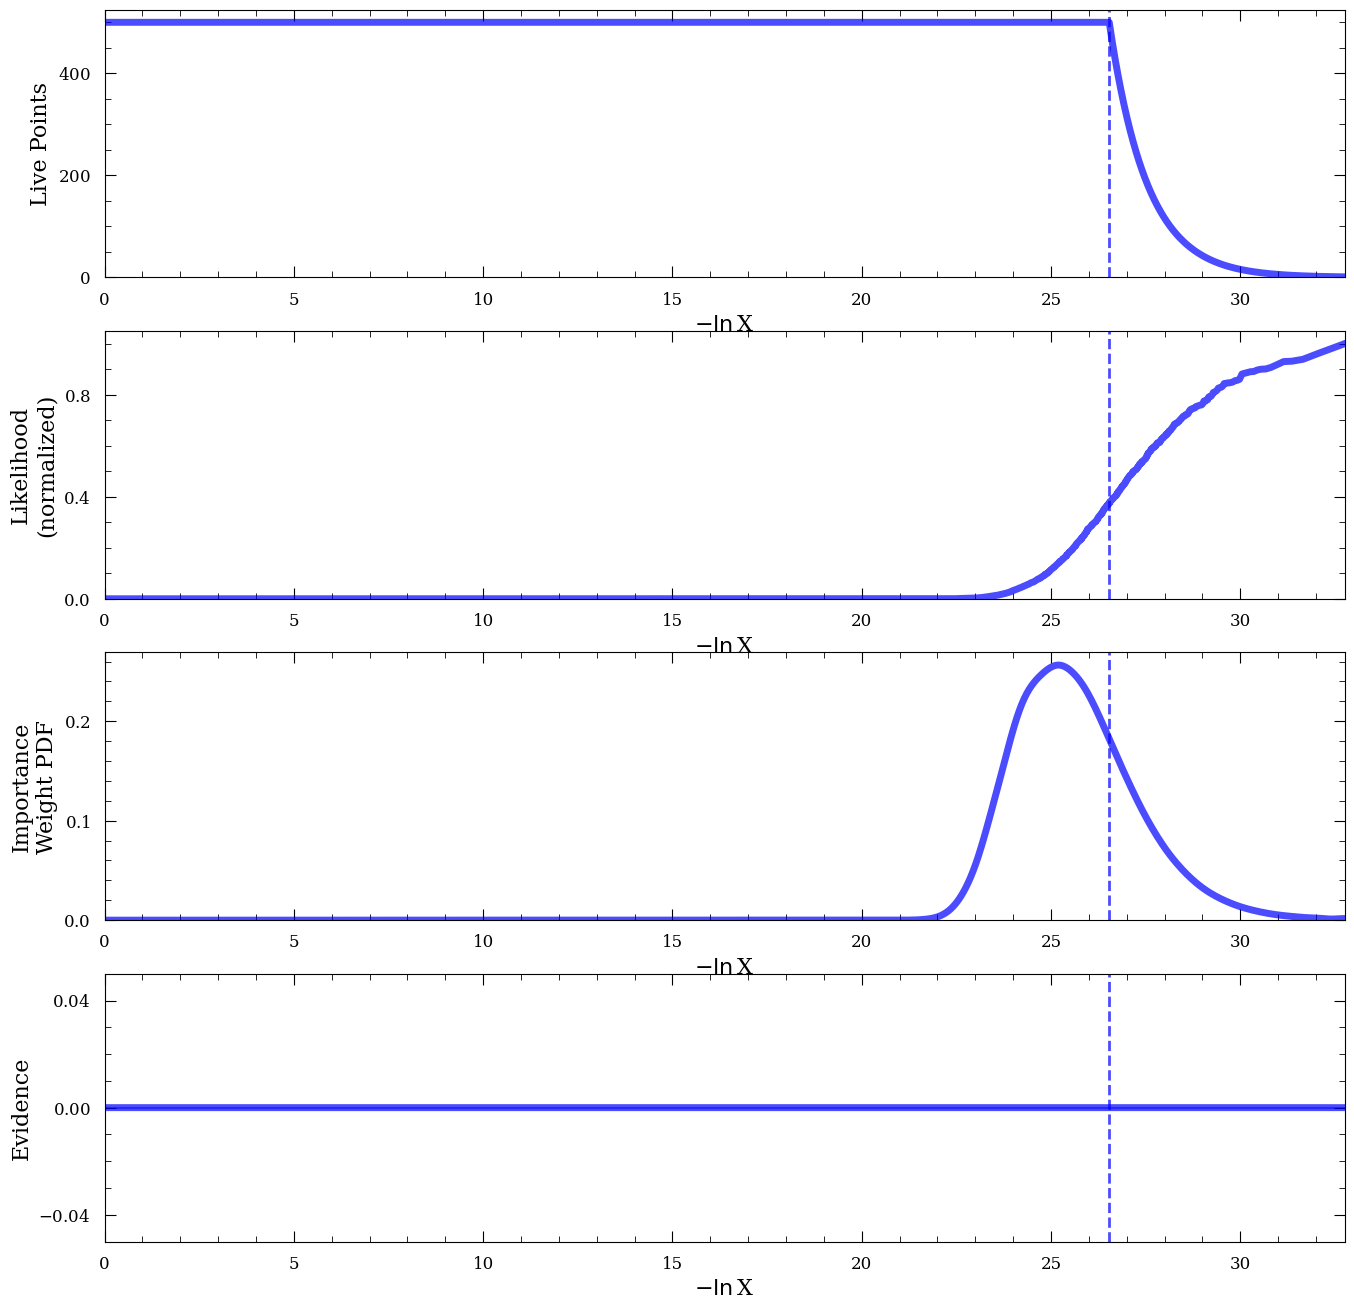

In [5]:
fig, axes = dyplot.runplot(results)

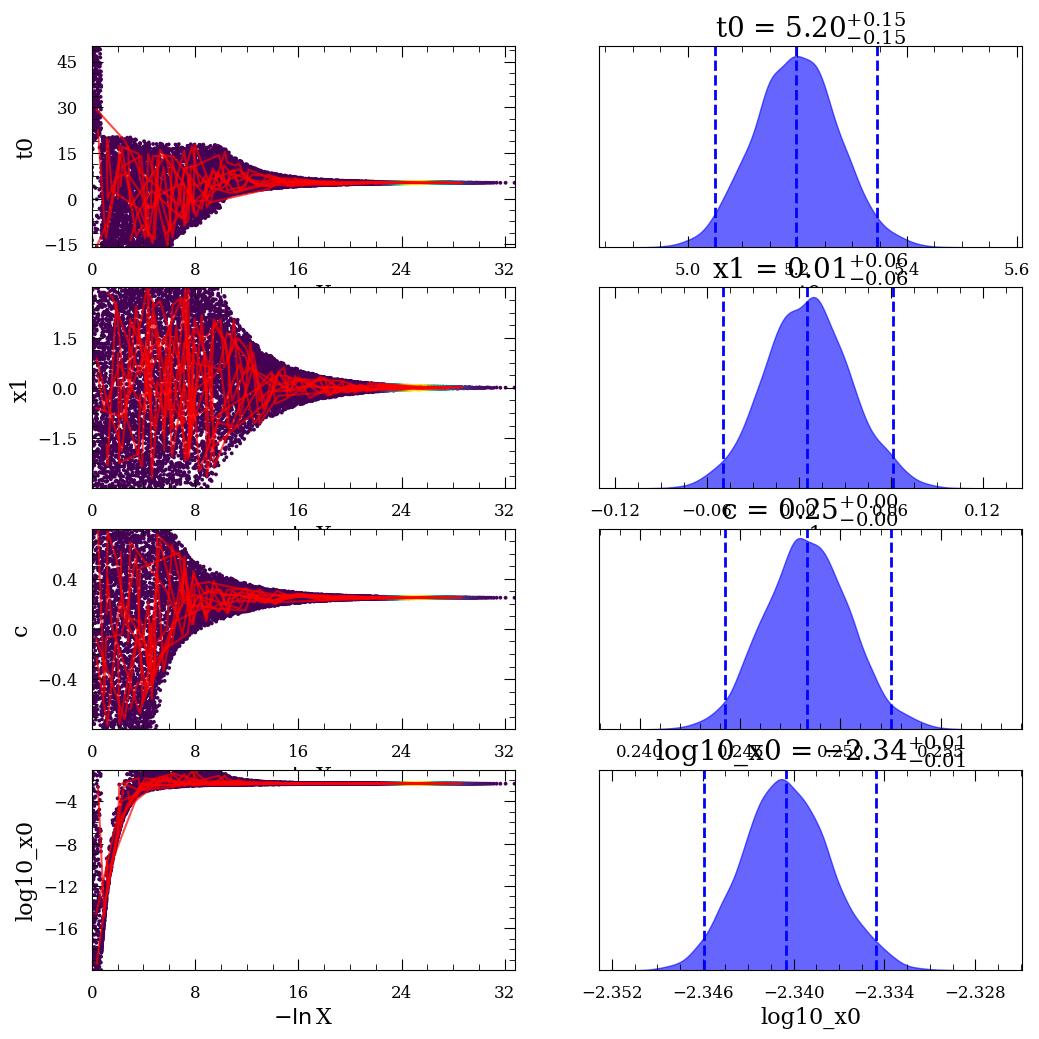

In [6]:
fig, axes = dyplot.traceplot(results, labels=params,show_titles=True,trace_cmap='viridis', connect=True)

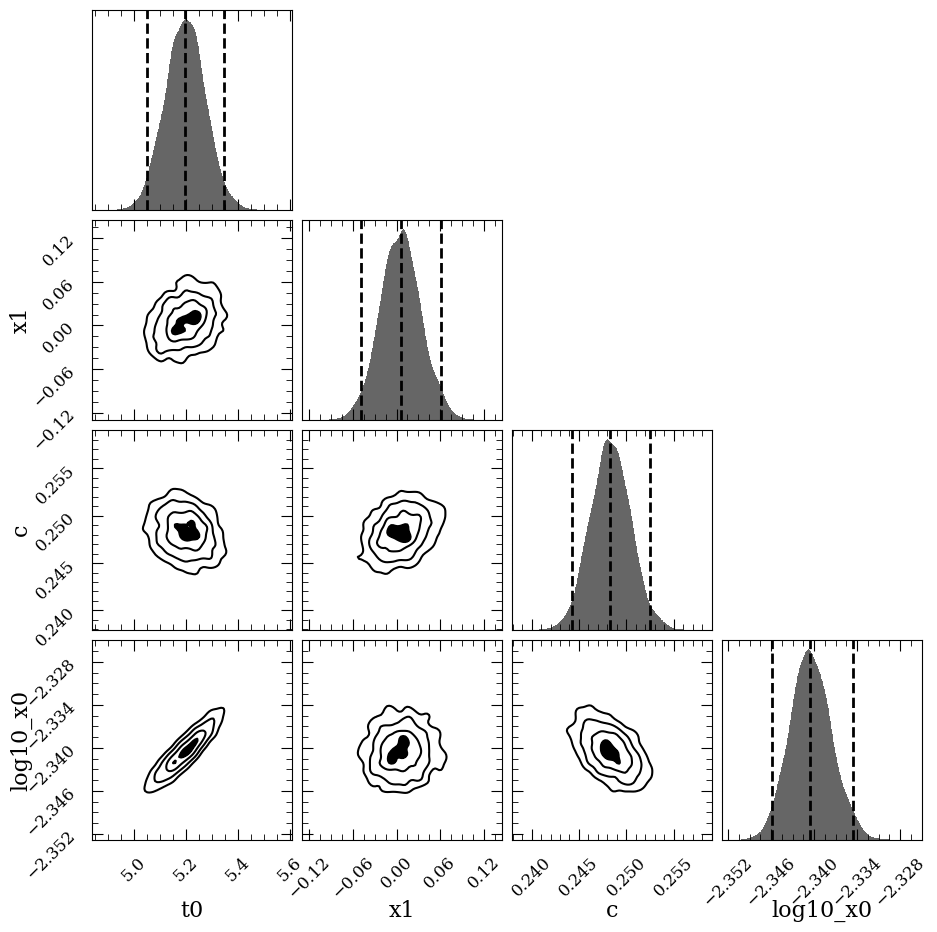

In [7]:
fig, axes = dyplot.cornerplot(results, labels=params)

In [8]:
FILE_NAME = '/Users/pxm588@student.bham.ac.uk/PhD/baysian_framework/test_spectra/sn2008ar-20080302.40-fast.flm'
REDSHIFT = 0.0151
MODELNAME = 'Hsiao'

base_name = os.path.splitext(os.path.basename(FILE_NAME))[0]
wave, flux, err = load_flm_spectrum(FILE_NAME)


# Trim to model range
mask = (wave > 3500) & (wave < 8000)
wave, flux, err = wave[mask], flux[mask], err[mask]

# Run fit
results, params = fit_spectrum_with_dynesty(wave, flux, err, MODELNAME, 500, redshift=0.0151)

# Process results
weights = np.exp(results.logwt - results.logz[-1])
samples = dynesty.utils.resample_equal(results.samples, weights)

t0_samples = samples[:, params.index('t0')]
age_samples = -t0_samples


# Saving plots with unique names
corner_file = f"{base_name}_corner.png"
fit_file = f"{base_name}_fit.png"

fig, axes = dyplot.cornerplot(results, labels=params)
plt.style.use('GausSN.mplstyle')
plt.savefig(corner_file)
plt.close(fig)

best_idx = np.argmax(results.logl)
best_params_raw = results.samples[best_idx]
p_dict = dict(zip(params, best_params_raw))

# Prep model for plotting
model = sncosmo.Model(MODELNAME)
model.set(z=REDSHIFT)


iter: 8282 | +500 | bound: 31 | nc: 1 | ncall: 32693 | eff(%): 27.279 | loglstar:   -inf < -18130.656 <    inf | logz: -18146.556 +/-  0.211 | dlogz:  0.001 >  0.509                                 

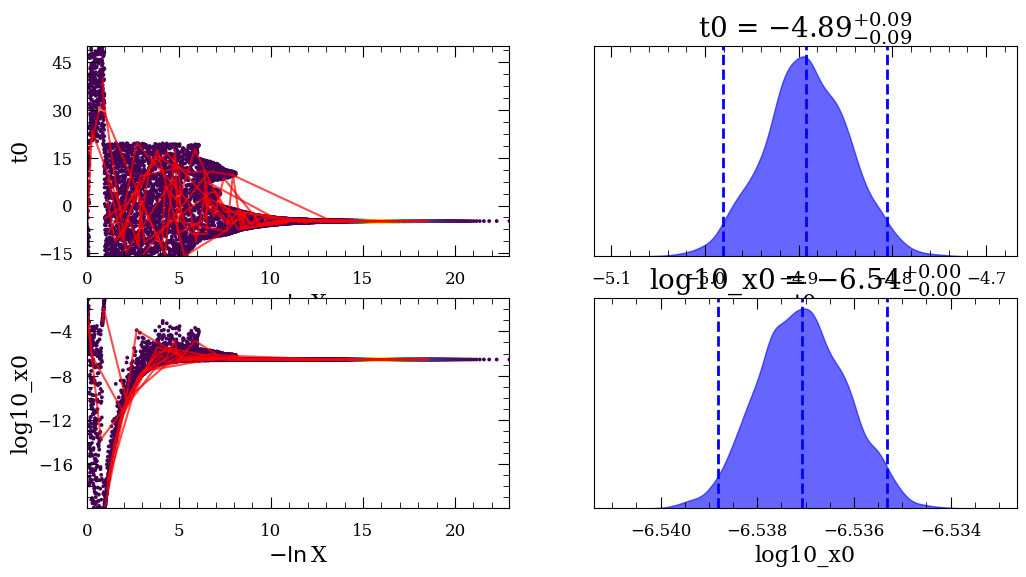

In [9]:
fig, axes = dyplot.traceplot(results, labels=params,show_titles=True,trace_cmap='viridis', connect=True)